# Dynamiqs check of the trained feedback-GRAPE policy with losses during readout and control

This notebook loads the trained recurrent feedback policy and reruns a few stochastic feedback trajectories, but the quantum dynamics are simulated with **Dynamiqs** instead of the custom solver used during training.

Compared with the first Dynamiqs cross-check, this version includes relaxation/dephasing in all three time windows of one feedback cycle:

1. a finite **readout window** of 2 us,
2. the usual **idle window** between measurements and feedback pulses,
3. the driven **control pulse**, now simulated with a Lindblad master equation instead of a unitary propagator.

The goal is not to train again. It is just a solver cross-check with clean plots that can be dropped into slides.


In [42]:
import os

# IMPORTANT:
# This notebook is only a solver cross-check with small Hilbert spaces.
# Forcing CPU avoids JAX/CUDA cuSolver/cuBLAS handle errors during small
# matrix initializations, matrix multiplications and eigensolvers.
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

import jax

print("jax", jax.__version__)
print("jaxlib", jax.lib.__version__)
print("JAX_PLATFORMS =", os.environ.get("JAX_PLATFORMS"))
print("LD_LIBRARY_PATH =", os.environ.get("LD_LIBRARY_PATH"))
print(jax.devices())


jax 0.6.2
jaxlib 0.6.2
JAX_PLATFORMS = cpu
LD_LIBRARY_PATH = None
[CpuDevice(id=0)]


In [43]:
import jax
import jax.numpy as jnp
from functools import partial

#jax.config.update("jax_enable_x64", True)

import optax
import flax.linen as nn
from flax.training.train_state import TrainState
 
import matplotlib.pyplot as plt
import numpy as np

import sys
import json
from pathlib import Path

try:
    from toolbox import *
except Exception as exc:
    print("Could not import toolbox.py. This is fine only if the fallback B-spline code is enough.")
    print(type(exc).__name__, exc)

import dynamiqs as dq

try:
    dq.set_progress_meter(False)
except Exception:
    pass


In [44]:

seed = 1234
key = jax.random.key(seed)
# # Forces JAX to use the asynchronous CUDA allocator, heavily reducing fragmentation
# import os
# os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "cuda_async"


# Load json

In [45]:

def _strip_comment_keys(obj):
    # Recursively drop any keys that start with '//'.
    if isinstance(obj, dict):
        return {k: _strip_comment_keys(v) for k, v in obj.items()
                if not (isinstance(k, str) and k.startswith("//"))}
    if isinstance(obj, list):
        return [_strip_comment_keys(x) for x in obj]
    return obj

def load_config_dict(config_directory: Path, filename: str = "configuration.json") -> dict:
    path = (config_directory / filename).resolve()
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    return _strip_comment_keys(data)

config_directory = Path("")
cfg = load_config_dict(config_directory, "configuration.json")

print("chi =", -cfg["chi_kHz"], "kHz")
print("qubit anharmonicity =", cfg["anharmonicity_MHz"], "MHz")

# Hamiltonian parameters (MHz units, i.e. angular frequency in rad / us)
chi = - 2 * jnp.pi * cfg["chi_kHz"] * 1e-3
qubit_anham = 2 * jnp.pi * cfg["anharmonicity_MHz"]
cavity_self_kerr = 2*jnp.pi*cfg["self_Kerr_kHz"]*1e-3  # cavity self-Kerr MHz

# Relaxation times
# These are used by Dynamiqs during the idle window.
t1_qub = cfg["qubit_T1_us"]
t2_qub = cfg["qubit_T2_us"]
t1_cav = cfg["storage_T1_us"]


chi = -660.8313 kHz
qubit anharmonicity = -164.271 MHz


## Problem parameters

#### Static constants

In [46]:

mu_qub = 20.0 #make the coeff big enough so that the amps remain betwee -2 and 2
mu_cav = 20.0


In [47]:

k = 2 #quartic bsplines (only 3 non zero bsplines simultaneously)
bspln_num = 20    # Desired number of basis pulses

# Skip exactly 'k' on both sides to use purely uniform interior splines
skip_left = k
skip_right = k
n = bspln_num + skip_left + skip_right  # Total knots required = 24

# Grid interval (delta) must be a multiple of 4ns. 
delta_ns = 64
m = n - k  # Total uniform intervals = 22

T_ns_hw = m * delta_ns
T_us_hw = T_ns_hw / 1000.0

time_start = 0.0
time_end = T_us_hw

# A degree k B-spline spans exactly k+1 intervals
L_ns = (k + 1) * delta_ns  

print("--- Pulse Properties ---")
print(f"B-spline Degree (k)     : {k}")
print(f"Grid step (delta_ns)    : {delta_ns} ns")
print(f"Single pulse length     : {L_ns} ns")
print(f"Total sequence duration : {T_ns_hw} ns ({T_us_hw} us)")
print(f"Max overlapping pulses  : {k + 1}")
print("------------------------")
assert L_ns % 4 == 0, "Pulse length is not a multiple of 4 ns!"


--- Pulse Properties ---
B-spline Degree (k)     : 2
Grid step (delta_ns)    : 64 ns
Single pulse length     : 192 ns
Total sequence duration : 1408 ns (1.408 us)
Max overlapping pulses  : 3
------------------------


In [48]:

t_drive = T_us_hw
ndt_drive = 200

num_bspln = bspln_num 
num_bspln


20

In [49]:

inp_shape = (1,)
osz = num_bspln * 4
rec_features = osz
dense_features = [int(osz * 2), int(osz * 3), int(osz * 2)]
learning_rate=0.00001

rec_features, dense_features


(80, [160, 240, 160])

#### Dynamic const

In [50]:
# Keep the same truncation as in the training notebook.
# If the Dynamiqs check is too slow on your machine, use N_cav = 16 for a first quick pass.
N_cav = 28

# One feedback cycle is modeled as:
# readout decay -> projective sz measurement and reset -> idle decay -> NN pulse with decay.
t_readout = 2.0 # readout duration in us
t_idle = 15 #in us on average

# Number of trajectories and feedback steps to cross-check.
# Increase num_time_steps_dynamiqs to 150 if you want the same long test as in the training notebook.
num_trajs = 3
num_time_steps_dynamiqs = 40

print("readout duration =", t_readout, "us")
print("idle duration    =", t_idle, "us")
print("control duration =", float(t_drive), "us")


readout duration = 2.0 us
idle duration    = 15 us
control duration = 1.408 us


## Small linear-algebra helpers

In [51]:

def hconj_np(x):
    return jnp.conj(jnp.swapaxes(x, -1, -2))

def ket(n, i, dtype=jnp.complex64):
    v = jnp.zeros((n, 1), dtype=dtype)
    return v.at[i, 0].set(1.0 + 0.0j)

def dm(psi):
    return psi @ hconj_np(psi)

def destroy_np(n, dtype=jnp.complex64):
    vals = jnp.sqrt(jnp.arange(1, n, dtype=jnp.float32)).astype(dtype)
    return jnp.diag(vals, k=1)

def qtoarray(x):
    try:
        return dq.to_jax(x)
    except Exception:
        return jnp.asarray(x)

def clean_dm(rho):
    rho = 0.5 * (rho + hconj_np(rho))
    return rho / jnp.trace(rho)


In [52]:

psi_target_cav = ket(N_cav, 2) 
psi_target_cav /= jnp.sqrt((hconj_np(psi_target_cav) @ psi_target_cav)[0, 0])

psi_init = jnp.kron(ket(2, 0), psi_target_cav)
rho_init = dm(psi_init)


## Time-grids and B-splines

In [53]:

# Fallback for the few B-spline utilities, in case toolbox.py is not on the path.
try:
    setup_bspline_builder
    bknots_on_interval
except NameError:
    from scipy.interpolate import BSpline

    def bknots_on_interval(a, b, n, k):
        m = n - k
        interior = np.linspace(a, b, m + 1)
        return np.concatenate([
            np.repeat(a, k),
            interior,
            np.repeat(b, k),
        ])

    def setup_bspline_builder(a, b, n, k, skip_left, skip_right):
        knots = bknots_on_interval(a, b, n, k)
        coeffs = np.eye(n)
        splines = [BSpline(knots, coeffs[i], k, extrapolate=False) for i in range(n)]

        def builder(ts):
            ts_np = np.asarray(ts)
            vals = np.stack([np.nan_to_num(s(ts_np), nan=0.0) for s in splines])
            vals = vals[skip_left:n-skip_right]
            return jnp.asarray(vals)

        return builder


In [54]:

t_drive_edges = jnp.linspace(0, t_drive, ndt_drive + 1)
t_drive_mids = (t_drive_edges[1:] + t_drive_edges[:-1]) / 2
t_drive_intvs = t_drive_edges[1:] - t_drive_edges[:-1]

bspline_builder = setup_bspline_builder(0, t_drive_edges[-1], n, k, skip_left, skip_right)

bsplns_mids = bspline_builder(t_drive_mids)
bsplns_edges = bspline_builder(t_drive_edges)

knots = bknots_on_interval(0, t_drive_edges[-1], n, k)
knots = np.unique(knots)


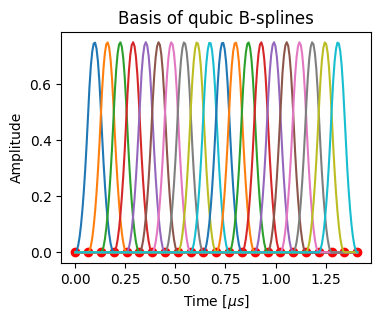

In [55]:

# TEST
fig, ax = plt.subplots(figsize=(4, 3))

for i in range(bsplns_edges.shape[0]):
    ax.plot(t_drive_edges, bsplns_edges[i])
        
ax.scatter(knots, np.zeros_like(knots), color="red");   
ax.set_xlabel(r"Time $[\mu s]$");
ax.set_ylabel("Amplitude");
ax.set_title("Basis of qubic B-splines");
# TEST


In [56]:

def ctrl_from_coeffs(ctrl_coeffs, bsplns):
    ctrls_real = ctrl_coeffs @ bsplns
    e_qub = ctrls_real[0, ...] + 1j * ctrls_real[1, ...]
    e_cav = ctrls_real[2, ...] + 1j * ctrls_real[3, ...]
    return e_qub, e_cav


## RNN

The network architecture is kept identical to the training notebook. The only small change is the dummy initializer for the GRU recurrent kernel: we avoid the default orthogonal initializer because it can call GPU QR/cuSolver during initialization. This does not affect the loaded checkpoint, because the trained weights overwrite the dummy initialization.


In [57]:
def init_carry(key, rec_features, inp_shape):
    gru_cell = nn.GRUCell(
        features=rec_features,
        recurrent_kernel_init=nn.initializers.glorot_uniform(),
    )
    return gru_cell.initialize_carry(key, inp_shape)

def create_flax_state(key,
                      rec_features, dense_features, inp_shape, learning_rate,
                      *, print_summary):
    
    class Model(nn.Module):
    
        @nn.compact
        def __call__(self, carry, x):
            
            gru_cell = nn.GRUCell(
                features=rec_features,
                recurrent_kernel_init=nn.initializers.glorot_uniform(),
            )
            carry, x = gru_cell(carry, x)
            
            for ndf in dense_features:
                x = nn.Dense(ndf)(x)
                x = jax.nn.relu(x)
                
            out_layer = nn.Dense(4 * num_bspln)
            x = out_layer(x)
            x = x.reshape(4, num_bspln)
            
            return carry, x

    model = Model()

    fake_key = jax.random.key(0)
    fake_carry = init_carry(fake_key, rec_features, inp_shape)
    fake_inp = jnp.ones(inp_shape)
    params = model.init(key, fake_carry, fake_inp)["params"]

    optimizer = optax.adam(learning_rate=learning_rate)

    flax_state = TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)

    if print_summary:
        print(model.tabulate(fake_key, fake_carry, fake_inp))

    return flax_state

def apply_nn(flax_state, params, carry, inp):
    return flax_state.apply_fn({'params': params}, carry, inp)


## Load trained state

In [58]:

def restore_trained_state(fld, flax_state):
    fld = Path(fld)
    if not fld.exists():
        raise FileNotFoundError(
            f"Could not find {fld.resolve()}. Run this notebook from the folder containing "
        )

    # If the toolbox already provides a loader, use it.
    if "load_flax_state" in globals():
        try:
            return load_flax_state(str(fld), flax_state)
        except TypeError:
            return load_flax_state(str(fld))

    # Otherwise restore the Orbax checkpoint written by save_flax_state().
    import orbax.checkpoint as ocp
    candidates = [fld / "1", fld]
    candidates += [p for p in sorted(fld.iterdir()) if p.is_dir()]

    last_exc = None
    for path in candidates:
        if not path.exists():
            continue
        try:
            ckptr = ocp.Checkpointer(ocp.StandardCheckpointHandler())
            if hasattr(ocp, "args"):
                return ckptr.restore(path, args=ocp.args.StandardRestore(flax_state))
            return ckptr.restore(path, item=flax_state)
        except Exception as exc:
            last_exc = exc

    raise RuntimeError(f"Found {fld}, but could not restore it with Orbax: {last_exc}")


In [59]:

trained_folder = Path("trained_nn15_readout_decay_whole_readout_20bs_fock_target")

key, subkey = jax.random.split(key)
flax_state = create_flax_state(
    subkey, rec_features, dense_features, inp_shape, learning_rate,
    print_summary=True
)




                                 Model Summary                                  
┏━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ path         ┃ module  ┃ inputs        ┃ outputs         ┃ params            ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│              │ Model   │ - float32[80] │ - float32[80]   │                   │
│              │         │ - float32[1]  │ - float32[4,20] │                   │
├──────────────┼─────────┼───────────────┼─────────────────┼───────────────────┤
│ GRUCell_0    │ GRUCell │ - float32[80] │ - float32[80]   │                   │
│              │         │ - float32[1]  │ - float32[80]   │                   │
├──────────────┼─────────┼───────────────┼─────────────────┼───────────────────┤
│ GRUCell_0/ir │ Dense   │ float32[1]    │ float32[80]     │ bias: float32[80] │
│              │         │               │                 │ kernel:           │
│              │         │ 

In [60]:
from pathlib import Path
import os
import struct
import numpy as np
import jax
import jax.numpy as jnp
from flax.core import freeze, unfreeze

trained_folder = Path("trained_nn15_readout_decay_whole_readout_20bs_fock_target")


def read_feedback_grape_weights_bin(folder):
    folder = Path(folder).expanduser().resolve()
    path = folder / "weights.bin"

    if not path.exists():
        raise FileNotFoundError(f"weights.bin not found at: {path}")

    arrays = []

    with open(path, "rb") as f:
        magic = f.read(8)
        if magic != b"GRUCPP01":
            raise ValueError(f"Wrong weights.bin header: {magic}")

        n_arrays = struct.unpack("i", f.read(4))[0]

        for k in range(n_arrays):
            ndim = struct.unpack("i", f.read(4))[0]
            shape = tuple(struct.unpack("i", f.read(4))[0] for _ in range(ndim))
            n = int(np.prod(shape))

            arr = np.frombuffer(f.read(4 * n), dtype=np.float32)
            arr = arr.reshape(shape).copy()
            arrays.append(arr)

    if len(arrays) != 17:
        raise ValueError(f"Expected 17 arrays, got {len(arrays)}")

    return arrays


def load_feedback_grape_weights_bin_into_flax_state(folder, flax_state):
    arrays = read_feedback_grape_weights_bin(folder)

    # This order is exactly the order used in your save_cpp_weights(...) cell.
    names = [
        ("GRUCell_0", "ir", "kernel"),
        ("GRUCell_0", "ir", "bias"),
        ("GRUCell_0", "hr", "kernel"),

        ("GRUCell_0", "iz", "kernel"),
        ("GRUCell_0", "iz", "bias"),
        ("GRUCell_0", "hz", "kernel"),

        ("GRUCell_0", "in", "kernel"),
        ("GRUCell_0", "in", "bias"),
        ("GRUCell_0", "hn", "kernel"),

        ("Dense_0", "kernel"),
        ("Dense_0", "bias"),

        ("Dense_1", "kernel"),
        ("Dense_1", "bias"),

        ("Dense_2", "kernel"),
        ("Dense_2", "bias"),

        ("Dense_3", "kernel"),
        ("Dense_3", "bias"),
    ]

    params = unfreeze(flax_state.params)

    print("Loading weights from:", Path(folder).resolve() / "weights.bin")
    print("JAX devices:", jax.devices())
    print()

    for arr, name in zip(arrays, names):
        if len(name) == 3:
            a, b, c = name
            old = params[a][b][c]
            expected_shape = old.shape
        else:
            a, b = name
            old = params[a][b]
            expected_shape = old.shape

        if arr.shape != expected_shape:
            raise ValueError(
                f"Shape mismatch for {name}:\n"
                f"  weights.bin shape = {arr.shape}\n"
                f"  flax_state shape  = {expected_shape}\n"
                "This means the current model architecture does not match the saved one."
            )

        new = jnp.asarray(arr, dtype=old.dtype)

        if len(name) == 3:
            params[a][b][c] = new
        else:
            params[a][b] = new

        print(f"{name}: {arr.shape} OK")

    flax_state = flax_state.replace(params=freeze(params))

    print()
    print("SUCCESS: loaded NN weights into flax_state.params")
    return flax_state


flax_state = load_feedback_grape_weights_bin_into_flax_state(
    trained_folder,
    flax_state,
)

Loading weights from: /home/user/python_experiments/train_feedback_grape/trained_nn15_readout_decay_whole_readout_20bs_fock_target/weights.bin
JAX devices: [CpuDevice(id=0)]

('GRUCell_0', 'ir', 'kernel'): (1, 80) OK
('GRUCell_0', 'ir', 'bias'): (80,) OK
('GRUCell_0', 'hr', 'kernel'): (80, 80) OK
('GRUCell_0', 'iz', 'kernel'): (1, 80) OK
('GRUCell_0', 'iz', 'bias'): (80,) OK
('GRUCell_0', 'hz', 'kernel'): (80, 80) OK
('GRUCell_0', 'in', 'kernel'): (1, 80) OK
('GRUCell_0', 'in', 'bias'): (80,) OK
('GRUCell_0', 'hn', 'kernel'): (80, 80) OK
('Dense_0', 'kernel'): (80, 160) OK
('Dense_0', 'bias'): (160,) OK
('Dense_1', 'kernel'): (160, 240) OK
('Dense_1', 'bias'): (240,) OK
('Dense_2', 'kernel'): (240, 160) OK
('Dense_2', 'bias'): (160,) OK
('Dense_3', 'kernel'): (160, 80) OK
('Dense_3', 'bias'): (80,) OK

SUCCESS: loaded NN weights into flax_state.params


## Dynamiqs operators

Static operators are built with NumPy first and then converted once to JAX arrays. This keeps the construction simple and avoids accidentally calling GPU BLAS for tiny matrices.


In [61]:
def _get_sigma_matrices_np():
    try:
        sigz_2 = np.asarray(sigma.z, dtype=np.complex64)
        sigp_2 = np.asarray(sigma.p, dtype=np.complex64)
        sigm_2 = np.asarray(sigma.m, dtype=np.complex64)
        return sigz_2, sigp_2, sigm_2
    except Exception:
        # Fallback convention matching H_disp = chi/2 * n * (I - sz):
        # qubit index 1 is the state that shifts the storage frequency.
        sigz_2 = np.array([[1, 0], [0, -1]], dtype=np.complex64)
        sigp_2 = np.array([[0, 0], [1, 0]], dtype=np.complex64)
        sigm_2 = np.array([[0, 1], [0, 0]], dtype=np.complex64)
        return sigz_2, sigp_2, sigm_2

sigz_2_np, sigp_2_np, sigm_2_np = _get_sigma_matrices_np()

I_qub_np = np.eye(2, dtype=np.complex64)
I_cav_np = np.eye(N_cav, dtype=np.complex64)
I_tot_np = np.eye(2 * N_cav, dtype=np.complex64)

a_cav_np = np.diag(np.sqrt(np.arange(1, N_cav, dtype=np.float32)).astype(np.complex64), k=1)
a_np = np.kron(I_qub_np, a_cav_np)
adag_np = np.conj(a_np.T)
n_phot_np = adag_np @ a_np

sigz_np = np.kron(sigz_2_np, I_cav_np)
sigp_np = np.kron(sigp_2_np, I_cav_np)
sigm_np = np.kron(sigm_2_np, I_cav_np)

chi_np = float(-2 * np.pi * cfg["chi_kHz"] * 1e-3)
cavity_self_kerr_np = float(2 * np.pi * cfg["self_Kerr_kHz"] * 1e-3)

# Same driven-frame Hamiltonian convention as the training notebook.
H_disp_np = (chi_np / 2) * n_phot_np @ (I_tot_np - sigz_np)
H_kerr_np = 0.0 * I_tot_np
# If needed:
# H_kerr_np = (cavity_self_kerr_np / 2) * (n_phot_np @ n_phot_np - n_phot_np)

H_drift_np = H_disp_np + H_kerr_np

# The readout and idle windows keep the same approximation as the original make_idle():
# no Hamiltonian phase evolution, only the Lindblad relaxation/dephasing channel.
H_idle_np = np.zeros_like(H_drift_np)
H_readout_np = np.zeros_like(H_drift_np)

# Convert once to JAX arrays, now on CPU.
I_tot = jnp.asarray(I_tot_np)
a = jnp.asarray(a_np)
adag = jnp.asarray(adag_np)
n_phot = jnp.asarray(n_phot_np)

sigz = jnp.asarray(sigz_np)
sigp = jnp.asarray(sigp_np)
sigm = jnp.asarray(sigm_np)

H_drift = jnp.asarray(H_drift_np)
H_idle = jnp.asarray(H_idle_np)
H_readout = jnp.asarray(H_readout_np)


In [62]:
def get_t_phi_qub(t1, t2):
    return 1 / ((1 / t2) - (1 / t1) / 2)

t_phi_qub = get_t_phi_qub(t1_qub, t2_qub)

c_ops = [
    1 / jnp.sqrt(t1_qub) * sigm,
    1 / jnp.sqrt(t_phi_qub) * sigz / jnp.sqrt(2),
    1 / jnp.sqrt(t1_cav) * a,
]

print("t_phi_qub =", float(t_phi_qub), "us")
print("Hilbert-space dimension =", 2 * N_cav)
print("Number of collapse operators =", len(c_ops))


t_phi_qub = 54.53834862385322 us
Hilbert-space dimension = 56
Number of collapse operators = 3


## Measurement and fidelity

In [63]:

def measure_sz(key, rho_init):
    N = rho_init.shape[-1] // 2
    p0 = jnp.trace(rho_init[:N, :N]).real
    p1 = jnp.trace(rho_init[N:, N:]).real
    probs = jnp.array([p0, p1])
    probs = jnp.clip(probs, 0.0, 1.0)
    probs = probs / probs.sum()

    outcome_indx = int(jax.random.choice(key, 2, p=probs))
    prob = probs[outcome_indx]
    
    if outcome_indx == 0:
        rho_fin_cav = rho_init[:N, :N] / prob
    else:
        rho_fin_cav = rho_init[N:, N:] / prob
    
    # Qubit reset, same convention as in the training notebook.
    rho_fin_qub = dm(ket(2, 0))
    rho_fin = jnp.kron(rho_fin_qub, rho_fin_cav)
    rho_fin = clean_dm(rho_fin)
    
    # Outcome definition
    outcome = 1 - 2 * outcome_indx
    
    return float(outcome), float(prob), rho_fin

def rho_cavity(rho):
    N = rho.shape[-1] // 2
    return rho[:N, :N] + rho[N:, N:]

def fidelity_cav(rho):
    rho_cav = rho_cavity(rho)
    fid = (hconj_np(psi_target_cav) @ rho_cav @ psi_target_cav)[0, 0].real
    return float(jnp.clip(fid, 0.0, 1.0))


## Dynamiqs time step

The important change is here:

- `dynamiqs_readout_decay()` propagates the density matrix for `t_readout = 2 us` before the projective measurement.
- `dynamiqs_drive()` now calls `dq.mesolve(...)` with the driven Hamiltonian and the same collapse operators, instead of computing a unitary propagator with `dq.sepropagator(...)`.

So the control pulse is no longer treated as lossless.


In [ ]:
def _mesolve_options():
    try:
        return dq.Options(save_states=False, progress_meter=False, assume_hermitian=True)
    except TypeError:
        return dq.Options(progress_meter=False)

def _final_state(result):
    if hasattr(result, "final_state"):
        return qtoarray(result.final_state)
    return qtoarray(result.states[-1])

def dynamiqs_lindblad(rho, H, tsave):
    result = dq.mesolve(
        H,
        [dq.asqarray(c) for c in c_ops],
        dq.asqarray(rho),
        tsave,
        method=dq.method.Tsit5(),
        options=_mesolve_options(),
    )
    return clean_dm(_final_state(result))

def dynamiqs_readout_decay(rho):
    tsave = jnp.array([0.0, float(t_readout)])
    return dynamiqs_lindblad(rho, dq.asqarray(H_readout), tsave)

def dynamiqs_idle(rho):
    tsave = jnp.array([0.0, float(t_idle)])
    return dynamiqs_lindblad(rho, dq.asqarray(H_idle), tsave)

# def make_drive_hamiltonian(es_qub, es_cav):
#     H = dq.asqarray(H_drift)

#     # Qubit drive: mu_qub * (e_qub * sigma+ + conj(e_qub) * sigma-)
#     H = H + dq.pwc(t_drive_edges, es_qub, dq.asqarray(mu_qub * sigp))
#     H = H + dq.pwc(t_drive_edges, jnp.conj(es_qub), dq.asqarray(mu_qub * sigm))

#     # Cavity drive: same swapped-I/Q convention as in the training htree.
#     H = H + dq.pwc(t_drive_edges, 1j * jnp.conj(es_cav), dq.asqarray(mu_cav * adag))
#     H = H + dq.pwc(t_drive_edges, -1j * es_cav, dq.asqarray(mu_cav * a))
#     return H

def make_drive_hamiltonian(es_qub, es_cav):
    H = dq.asqarray(H_drift)

    # Qubit drive: exactly matching training htree
    H = H + dq.pwc(t_drive_edges, es_qub, dq.asqarray(mu_qub * sigp))
    H = H + dq.pwc(t_drive_edges, jnp.conj(es_qub), dq.asqarray(mu_qub * sigm))

    # Cavity drive: exactly matching training htree
    H = H + dq.pwc(t_drive_edges, jnp.conj(es_cav), dq.asqarray(mu_cav * adag))
    H = H + dq.pwc(t_drive_edges, es_cav, dq.asqarray(mu_cav * a))

    return H

def dynamiqs_drive(rho, es_qub, es_cav):
    H = make_drive_hamiltonian(es_qub, es_cav)

    # Use the full B-spline time grid as save grid so the ODE solver sees the
    # same piecewise-constant control intervals used to define dq.pwc(...).
    rho_fin = dynamiqs_lindblad(rho, H, t_drive_edges)
    return clean_dm(rho_fin)


In [65]:
def dynamiqs_time_step(key, rho, flax_state, params, carry):
    # Finite measurement duration. We propagate the state through the 2 us
    # readout window before sampling the same projective sz measurement used
    # in the training notebook.
    rho = dynamiqs_readout_decay(rho)
    meas_out, prob, rho = measure_sz(key, rho)
    fid_after_readout = fidelity_cav(rho)

    # Free evolution / waiting time between measurement and control.
    rho = dynamiqs_idle(rho)
    fid_after_idle = fidelity_cav(rho)

    # Recurrent policy and lossy driven control.
    rnn_inp = jnp.array([meas_out], dtype=float)
    carry, ctrl_coeffs = apply_nn(flax_state, params, carry, rnn_inp)
    es_qub, es_cav = ctrl_from_coeffs(ctrl_coeffs, bsplns_mids)

    rho = dynamiqs_drive(rho, es_qub, es_cav)
    fid_after_control = fidelity_cav(rho)

    return (
        rho, carry,
        fid_after_readout, fid_after_idle, fid_after_control,
        meas_out, prob, ctrl_coeffs, es_qub, es_cav,
    )


## Trajectories

In [66]:
def run_one_dynamiqs_trajectory(key, flax_state, num_time_steps, store_first_pulses=8):
    key_carry, key = jax.random.split(key)
    carry = init_carry(key_carry, rec_features, inp_shape)
    rho = rho_init

    fids_after_readout = []
    fids_after_idle = []
    fids_after_control = []
    meas_outs = []
    probs = []
    pulses = []

    for i in range(num_time_steps):
        key, subkey = jax.random.split(key)
        (
            rho, carry,
            fid_ro, fid_idle, fid_ctrl,
            meas_out, prob, ctrl_coeffs, es_qub, es_cav,
        ) = dynamiqs_time_step(subkey, rho, flax_state, flax_state.params, carry)

        fids_after_readout.append(fid_ro)
        fids_after_idle.append(fid_idle)
        fids_after_control.append(fid_ctrl)
        meas_outs.append(meas_out)
        probs.append(prob)

        if i < store_first_pulses:
            pulses.append({
                "ctrl_coeffs": np.asarray(ctrl_coeffs),
                "e_qub": np.asarray(es_qub),
                "e_cav": np.asarray(es_cav),
            })

        print(
            "step", i,
            "fid_ro", fid_ro,
            "fid_idle", fid_idle,
            "fid_ctrl", fid_ctrl,
            "meas", meas_out,
            "prob", prob,
        )

    return {
        # Keep the short key 'fids' for compatibility with the plotting cells.
        "fids": np.asarray(fids_after_control),
        "fids_after_readout": np.asarray(fids_after_readout),
        "fids_after_idle": np.asarray(fids_after_idle),
        "fids_after_control": np.asarray(fids_after_control),
        "meas_outs": np.asarray(meas_outs),
        "probs": np.asarray(probs),
        "rho_final": np.asarray(rho),
        "pulses": pulses,
    }


In [67]:

key, subkey = jax.random.split(key)
traj_keys = jax.random.split(subkey, num_trajs)

traj_data = []
for i, ktraj in enumerate(traj_keys):
    print("\n--- trajectory", i, "---")
    traj_data.append(run_one_dynamiqs_trajectory(ktraj, flax_state, num_time_steps_dynamiqs))



--- trajectory 0 ---
step 0 fid_ro 0.9828991293907166 fid_idle 0.8636264204978943 fid_ctrl 0.6970406174659729 meas 1.0 prob 0.9556615352630615
step 1 fid_ro 0.36072975397109985 fid_idle 0.3513164818286896 fid_ctrl 0.3557734191417694 meas -1.0 prob 0.3481677770614624
step 2 fid_ro 0.2845740020275116 fid_idle 0.29101860523223877 fid_ctrl 0.23957887291908264 meas -1.0 prob 0.6124493479728699
step 3 fid_ro 0.23157404363155365 fid_idle 0.24948547780513763 fid_ctrl 0.313326358795166 meas 1.0 prob 0.4901840388774872
step 4 fid_ro 0.2645981013774872 fid_idle 0.2621920108795166 fid_ctrl 0.2863906919956207 meas -1.0 prob 0.5148075819015503
step 5 fid_ro 0.35213375091552734 fid_idle 0.33502358198165894 fid_ctrl 0.3392440676689148 meas 1.0 prob 0.4522956907749176
step 6 fid_ro 0.4374615550041199 fid_idle 0.40139272809028625 fid_ctrl 0.372549831867218 meas 1.0 prob 0.4954695403575897
step 7 fid_ro 0.5131348371505737 fid_idle 0.46741366386413574 fid_ctrl 0.4197750687599182 meas 1.0 prob 0.513955593

## Basic sanity checks

In [68]:
for i, traj in enumerate(traj_data):
    rho = np.asarray(traj["rho_final"])
    rho_h = 0.5 * (rho + np.conj(rho.T))

    tr = np.trace(rho)
    herm_err = np.linalg.norm(rho - np.conj(rho.T))
    min_eval = np.linalg.eigvalsh(rho_h).min().real

    print(
        f"traj {i}: final fid={traj['fids'][-1]:.5f}, "
        f"trace={tr:.8f}, herm_err={herm_err:.2e}, min_eval={min_eval:.2e}"
    )


traj 0: final fid=0.26459, trace=1.00000000+0.00000000j, herm_err=0.00e+00, min_eval=9.49e-06
traj 1: final fid=0.20265, trace=0.99999994+0.00000000j, herm_err=0.00e+00, min_eval=1.41e-05
traj 2: final fid=0.24777, trace=0.99999994+0.00000000j, herm_err=0.00e+00, min_eval=4.19e-06


## Example closed-loop trajectories

The plots below show a few representative closed-loop trajectories of the feedback policy.  
The lower x-axis is the feedback step index, while the upper x-axis shows the corresponding elapsed time since the beginning of the experiment.  
For each trajectory, the title also reports the mean fidelity along the full trajectory.

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FormatStrFormatter

def _extract_measurements(traj):
    for key in ["meas_outs", "measurements", "meas", "outcomes", "ms", "m_record"]:
        if key in traj:
            return np.asarray(traj[key])
    raise KeyError("Could not find measurement outcomes in the trajectory dict.")

# One full feedback cycle:
# readout decay -> measurement/reset -> idle decay -> control pulse
t_control_us = float(t_drive)
step_time_us = float(t_readout + t_idle + t_control_us)

print(f"Readout time  : {t_readout:.3f} us")
print(f"Idle time     : {t_idle:.3f} us")
print(f"Control time  : {t_control_us:.3f} us")
print(f"Cycle time    : {step_time_us:.3f} us per feedback step")

Readout time  : 2.000 us
Idle time     : 15.000 us
Control time  : 1.408 us
Cycle time    : 18.408 us per feedback step


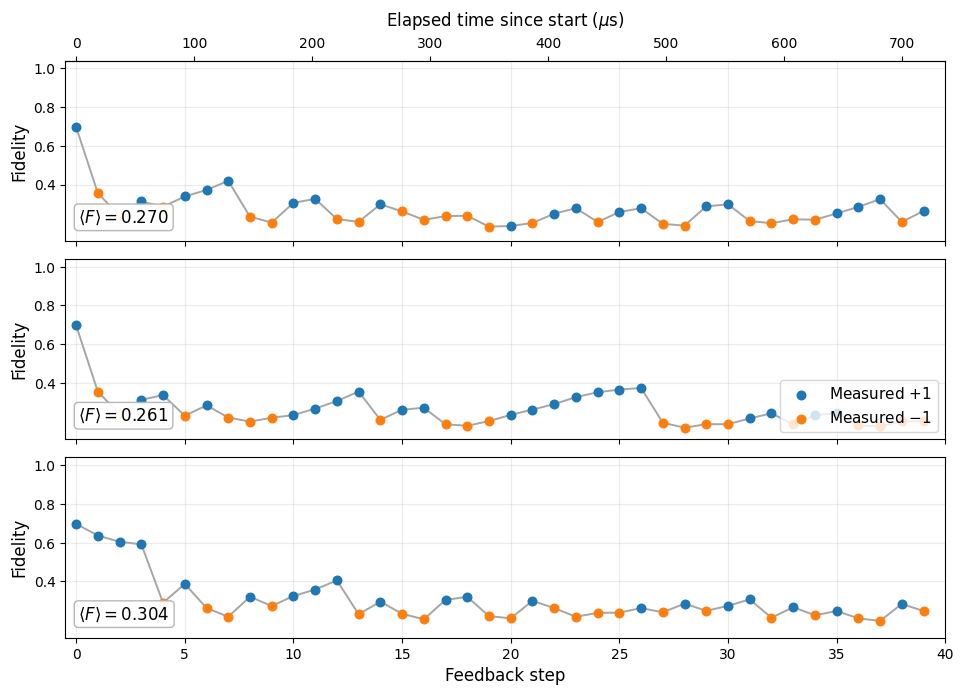

Overall mean fidelity across shown trajectories: 0.27834
Trajectory 1: mean fidelity = 0.26984
Trajectory 2: mean fidelity = 0.26093
Trajectory 3: mean fidelity = 0.30425


In [70]:
plt.close("all")

n_show = min(3, len(traj_data))

fig, axes = plt.subplots(
    n_show, 1,
    figsize=(10.0, 7.8),
    sharex=True
)

if n_show == 1:
    axes = [axes]

all_fids = [
    np.asarray(traj_data[i]["fids_after_control"], dtype=float)
    for i in range(n_show)
]
all_fids_concat = np.concatenate(all_fids)

ymin = max(0.0, np.min(all_fids_concat) - 0.06)
ymax = 1.04

trajectory_means = []
legend_handles = None

for i, ax in enumerate(axes):
    traj = traj_data[i]
    fids = np.asarray(traj["fids_after_control"], dtype=float)
    meas = _extract_measurements(traj)

    steps = np.arange(len(fids))

    pos = meas > 0
    neg = meas < 0

    ax.plot(
        steps,
        fids,
        color="0.65",
        lw=1.4,
        zorder=1
    )

    p1 = ax.scatter(
        steps[pos],
        fids[pos],
        s=38,
        color="tab:blue",
        label=r"Measured $+1$",
        zorder=3
    )

    p2 = ax.scatter(
        steps[neg],
        fids[neg],
        s=38,
        color="tab:orange",
        label=r"Measured $-1$",
        zorder=3
    )

    if legend_handles is None:
        legend_handles = [p1, p2]

    mean_fid = np.mean(fids)
    trajectory_means.append(mean_fid)

    ax.text(
        0.015,
        0.08,
        rf"$\langle F \rangle = {mean_fid:.3f}$",
        transform=ax.transAxes,
        fontsize=12,
        va="bottom",
        ha="left",
        bbox=dict(
            boxstyle="round,pad=0.25",
            fc="white",
            ec="0.70",
            alpha=0.95
        )
    )

    ax.set_ylabel("Fidelity", fontsize=12)
    ax.set_ylim(ymin, ymax)
    ax.set_yticks([0.4, 0.6, 0.8, 1.0])
    ax.grid(True, alpha=0.25)

    ax.spines["right"].set_visible(True)

# Put legend inside the second subplot, bottom right
legend_ax = axes[1] if n_show >= 2 else axes[0]
legend_ax.legend(
    handles=legend_handles,
    labels=[r"Measured $+1$", r"Measured $-1$"],
    loc="lower right",
    frameon=True,
    fontsize=11,
    ncol=1
)

axes[-1].set_xlabel("Feedback step", fontsize=12)
axes[-1].xaxis.set_major_locator(MaxNLocator(integer=True))

# Top x-axis: elapsed time
def step_to_time(step):
    return step * step_time_us

def time_to_step(time_us):
    return time_us / step_time_us

secax = axes[0].secondary_xaxis("top", functions=(step_to_time, time_to_step))
secax.set_xlabel(r"Elapsed time since start ($\mu$s)", fontsize=12, labelpad=8)
secax.xaxis.set_major_formatter(FormatStrFormatter("%.0f"))

overall_mean = np.mean(all_fids_concat)


# Important: enough room for title + top x-axis, and no subplot overlap
fig.subplots_adjust(
    left=0.10,
    right=0.98,
    bottom=0.08,
    top=0.82,
    hspace=0.10
)

n_steps = len(all_fids[0])  # or len(fids) if all trajectories have same length
for ax in axes:
    ax.set_xlim(-0.5, n_steps - 0.5 + 0.5)

output_dir = Path("feedback_grape_trajectories")
output_dir.mkdir(exist_ok=True)
fig.savefig(output_dir / "feedback_grape_trajectories_clean.pdf")
fig.savefig(output_dir / "feedback_grape_trajectories_clean.png", dpi=300)

plt.show()

print(f"Overall mean fidelity across shown trajectories: {overall_mean:.5f}")
for i, m in enumerate(trajectory_means):
    print(f"Trajectory {i+1}: mean fidelity = {m:.5f}")